# 多層パーセプトロンの実装
---
## 目的
これまでに学習した内容を活用して，多層パーセプトロンを実装し学習を行う．

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

### 多層パーセプトロン（Multi Layer erceptron: MLP）
多層パーセプトロンは，複数の層（入力層，隠れ層，出力層）から成るニューラルネットワークの一種です．層ごとに重みとバイアスを持ち，それぞれのユニット（形式ニューロン）は活性化関数によって出力を生成します．

**MLPの構造**:<br>
- 入力層（Input Layer）：入力データが与えられる層．ユニット数は入力の次元数に等しい．<br>
- 隠れ層（Hidden Layer）：入力層と出力層の間にある層．非線形な特徴を学習するのに役立ちます．複数の隠れ層が存在する場合，それを深層学習と呼びます．<br>
- 出力層（Output Layer）：ニューラルネットワークの出力を生成する層．出力の数は問題によって異なります．例えば，2クラス分類の場合は2，多クラス分類の場合はクラス数となります．<br>


隠れ層のユニット数を $h$ ，出力の次元数（クラス数）を $c$ とし，入力を$\boldsymbol{x}\in\mathbb{R}^{D}$ ，重み行列を $W\in\mathbb{R}^{h\times D}$ ，バイアスを$\boldsymbol{b}\in\mathbb{R}^{h}$，活性化関数を$f$とすると，隠れ層の出力は以下のように表されます:

$$ \boldsymbol{a} = f(W\boldsymbol{x} + \boldsymbol{b}) $$

最終的な出力を生成するために，出力層でも同様の操作を行います．<br>
出力を$\boldsymbol{y}\in\mathbb{R}^{c}$，出力層の重み行列を$W'\in\mathbb{R}^{c \times h}$，バイアスを$\boldsymbol{b'}\in\mathbb{R}^{c}$，出力層の活性化関数を$g$とすると，出力は以下のように表されます:

$$ \boldsymbol{y} = g(W'\boldsymbol{a} + \boldsymbol{b'}) $$


【Pytorchでのモデル定義】<br>
MLPは，複数のユニットを積み重ねることで設計することができます．<br>
そこで，今回は**多層パーセプトロンによるXOR回路**を作成します．<br>
XOR回路は2つの入力がともに異なる場合にのみ，出力が1となります．下記の表はXOR回路の真理値表を示しています．
| 入力1 | 入力2 | 出力 |
|-------|-------|------|
|   0   |   0   |   0  |
|   0   |   1   |   1  |
|   1   |   0   |   1  |
|   1   |   1   |   0  |

下図のように，<u>XOR回路は１本の線でグループを分類できない</u>ため，線形分離不可能な問題となります．<br>
つまり，非線形問題を扱うことが可能なMLPの性能を評価するのに適した問題といえます．

<left>
<img src=https://onedrive.live.com/embed?resid=B8367B1E7E59C516%21562416&authkey=%21AEBrlC9wQi6BTWA&width=298&height=216
width=60%>
<br>
</left>

In [2]:
# XORゲートの学習データ
training_data = [
    (torch.tensor([0.0, 0.0]), torch.tensor([0.0])),
    (torch.tensor([0.0, 1.0]), torch.tensor([1.0])),
    (torch.tensor([1.0, 0.0]), torch.tensor([1.0])),
    (torch.tensor([1.0, 1.0]), torch.tensor([0.0])),
]

1. ネットワーククラスの定義：<br>
はじめにネットワークのクラスを定義します．これはnn.Moduleを継承するクラスで，__init__メソッドでネットワークの構造を初期化し，forwardメソッドでデータのフォワードパスを定義します．<br>
本モデルでは入力層のユニット数は引数input_sizeとして与え，隠れ層のユニット数は引数hidden_size，出力はスカラー値であるので1とします．また，活性化関数にはシグモイド関数を用います．

In [3]:
class XORModel(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(XORModel, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)  # 2つの入力を受け取り，2つの出力を返す
        self.activation1 = nn.Sigmoid()
        self.layer2 = nn.Linear(hidden_size, 1)  # 2つの入力を受け取り，1つの出力を返す
        self.activation2 = nn.Sigmoid()

    def forward(self, x):
        x = self.activation1(self.layer1(x))
        x = self.activation2(self.layer2(x))
        return x

**__init__メソッド**: ネットワークの初期化を行います．ここで，入力層から隠れ層への線形変換（nn.Linear）とその後の活性化関数（シグモイド）を定義し，隠れ層から出力層への線形変換とその後の活性化関数も同様に定義しています．

 **forwardメソッド**: データのフォワードパスを定義します．具体的には，隠れ層に入力データを与え，その結果を活性化関数にかけた後，出力層に渡して最終的な出力を得ています．

2. モデルのインスタンス化:<br>
定義したクラスからモデルのインスタンスを作成します．これには，入力サイズと隠れ層サイズを指定します．

In [4]:
# モデルのインスタンス化
model = XORModel(input_size=2, hidden_size=2)
print(model)

XORModel(
  (layer1): Linear(in_features=2, out_features=2, bias=True)
  (activation1): Sigmoid()
  (layer2): Linear(in_features=2, out_features=1, bias=True)
  (activation2): Sigmoid()
)


3. 損失関数および最適化手法の定義:<br>
ネットワークがどれだけ問題に適合しているかを計算するために，損失関数を定義します．2値分類問題においては，一般的には二値交差エントロピー損失（Binary Cross Entropy Loss）が使われます．<br>
また，パラメータの更新には最適化手法を定義します．今回は，確率的勾配降下法 (Stochastic Gradient Descent: SGD) を使用します．

In [5]:
# 損失関数とオプティマイザの定義
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=1.5)

4. モデルの学習:
モデルを学習させます．エポック数やバッチサイズなどのハイパーパラメータを設定します．今回は，1データごとに学習を行うオンライン学習で実装します．<br>
学習の際は下記のコマンドを実行します，<br>
optimizer.zero_grad(): 勾配を初期化します．<br>
loss.backward(): 勾配の計算を行います．<br>
optimizer.step(): パラメータの更新を行います．<br>

Epoch 100/1000, Loss: 0.7265846394002438
Epoch 200/1000, Loss: 0.6450056673493236
Epoch 300/1000, Loss: 0.6379211585735902
Epoch 400/1000, Loss: 0.5627292734570801
Epoch 500/1000, Loss: 0.016639609588310122
Epoch 600/1000, Loss: 0.008109222981147468
Epoch 700/1000, Loss: 0.005359170609153807
Epoch 800/1000, Loss: 0.003999048727564514
Epoch 900/1000, Loss: 0.0031878052395768464
Epoch 1000/1000, Loss: 0.002649169007781893


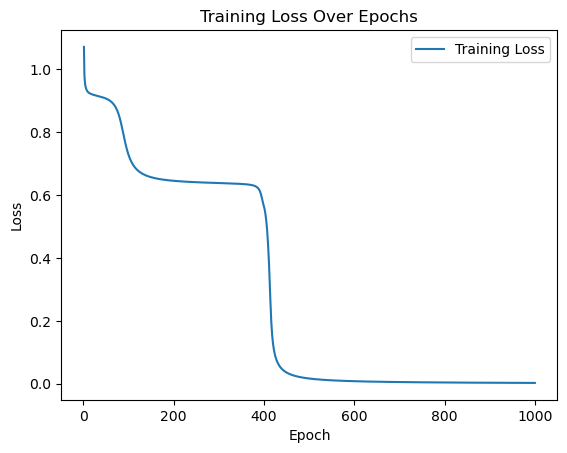

In [6]:
num_epochs = 1000

# 損失の履歴を保存するためのリスト
loss_history = []

# 学習
for epoch in range(num_epochs):
    total_loss = 0
    for input_data, target in training_data:
        optimizer.zero_grad()  # 勾配の初期化
        output = model(input_data)  # フォワードパス
        loss = criterion(output, target)  # 損失の計算
        loss.backward()  # バックワードパス（勾配の計算）
        optimizer.step()  # パラメータの更新
        total_loss += loss.item()
    loss_history.append(total_loss / len(training_data))
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss / len(training_data)}')

# 学習の推移をグラフ化
plt.plot(range(1, num_epochs + 1), loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

5. 学習結果の確認:
学習が終わったら，モデルが正しく学習できたかを評価します．

Input: [0. 0.], Predicted Output: 0.0021855649538338184
Input: [0. 1.], Predicted Output: 0.9976667165756226
Input: [1. 0.], Predicted Output: 0.9976102113723755
Input: [1. 1.], Predicted Output: 0.003611214691773057


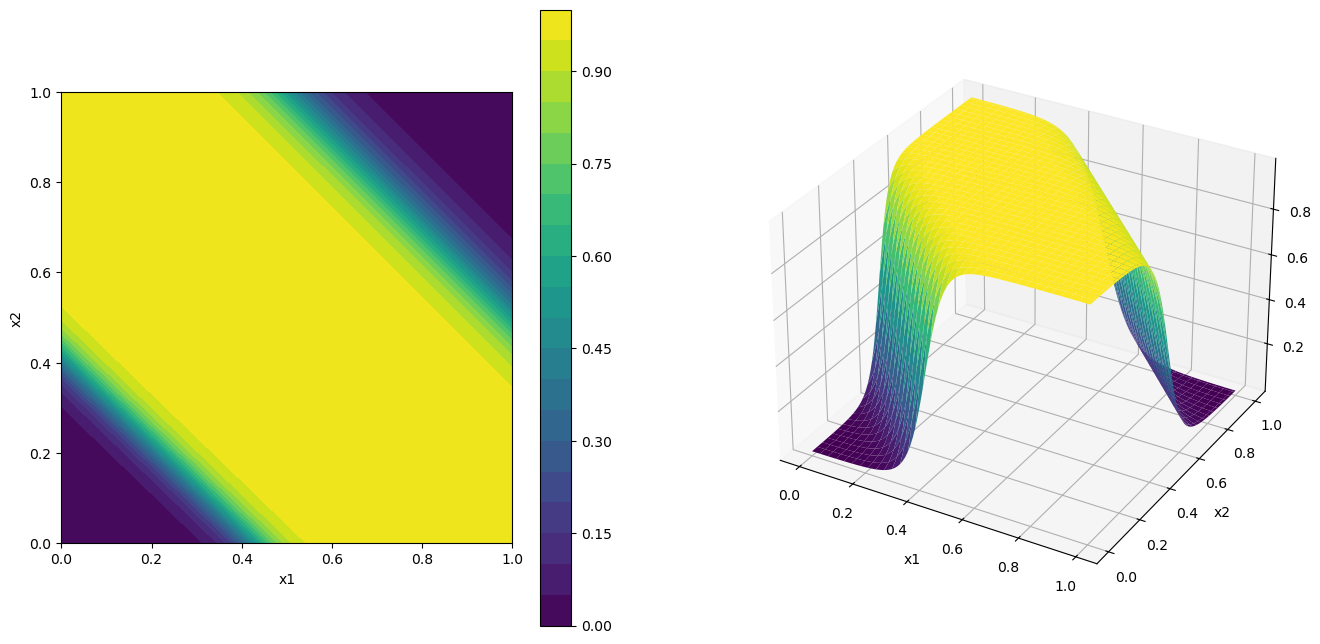

In [7]:
# 学習後のモデルの評価
with torch.no_grad():
    for input_data, _ in training_data:
        prediction = model(input_data)
        print(f'Input: {input_data.numpy()}, Predicted Output: {prediction.item()}')

## 結果を視覚的に出力
# x1とx2の生成
x1 = np.linspace(0, 1, 101)  # [0 0.1 ... 1.0]
x2 = np.linspace(0, 1, 101)  # [0 0.1 ... 1.0]
X1, X2 = np.meshgrid(x1, x2)

# 入力x1とx2の出力を計算しvalに代入
val = []

# perceptron の forward メソッドの戻り値が PyTorch テンソルなので numpy に変換
for v in x2:
    for u in x1:
        input_data = torch.tensor([u, v], dtype=torch.float32)
        output = model.forward(input_data).detach().numpy()
        val.append(output)

val = np.asarray(val)
val = val.reshape(X1.shape)


fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(121)
   
surf = ax.contourf(X1, X2, val, 20, cmap='viridis')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect('equal') 

ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X1, X2, val, cmap='viridis') 
ax.set_xlabel("x1")
ax.set_ylabel("x2")
fig.colorbar(surf)
plt.show()

---
### 【補足】<br>
単純パーセプトロンは，非線形な問題を扱うことができないことを下記で確認しましょう．

$$f(\boldsymbol{x})=
\begin{cases}
1 & (\boldsymbol{w} \cdot \boldsymbol{x} + \boldsymbol{b} > 0) \\
0 & (\boldsymbol{w} \cdot \boldsymbol{x} + \boldsymbol{b} \leq 0)
\end{cases}$$
ここで，$\boldsymbol{w} $ は重みベクトル，$\boldsymbol{x}$  は入力ベクトル，$\boldsymbol{b}$ はバイアスです．このモデルでは，活性化関数として用いられるのはステップ関数です．ステップ関数は非線形ではなく，単なる入力に対する閾値のようなものです．
一方で，シグモイド関数を活性化関数として導入した場合：
$$y = \sigma(\boldsymbol{w}  \cdot \boldsymbol{x} + b)$$
ここで，$\sigma$ はシグモイド関数です．シグモイド関数は非線形で，入力に対して滑らかな非線形変換を行います．しかし，単純パーセプトロンのモデル自体が単一のニューロンの構造しか持たず，複雑な非線形関数を表現する能力が限られています．

ANDModel(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)
Epoch 100/1000, Loss: 1.4138557314872742
Epoch 200/1000, Loss: 1.4138557314872742
Epoch 300/1000, Loss: 1.4138557314872742
Epoch 400/1000, Loss: 1.4138557314872742
Epoch 500/1000, Loss: 1.4138557314872742
Epoch 600/1000, Loss: 1.4138557314872742
Epoch 700/1000, Loss: 1.4138557314872742
Epoch 800/1000, Loss: 1.4138557314872742
Epoch 900/1000, Loss: 1.4138557314872742
Epoch 1000/1000, Loss: 1.4138557314872742


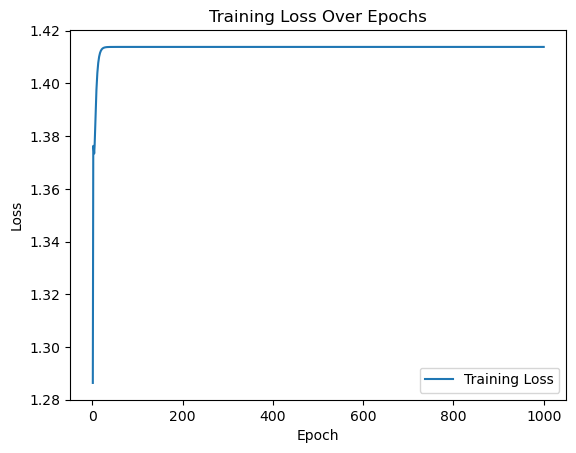

Input: [0. 0.], Predicted Output: 0.7567960619926453
Input: [0. 1.], Predicted Output: 0.49999988079071045
Input: [1. 0.], Predicted Output: 0.24320366978645325
Input: [1. 1.], Predicted Output: 0.09360524266958237


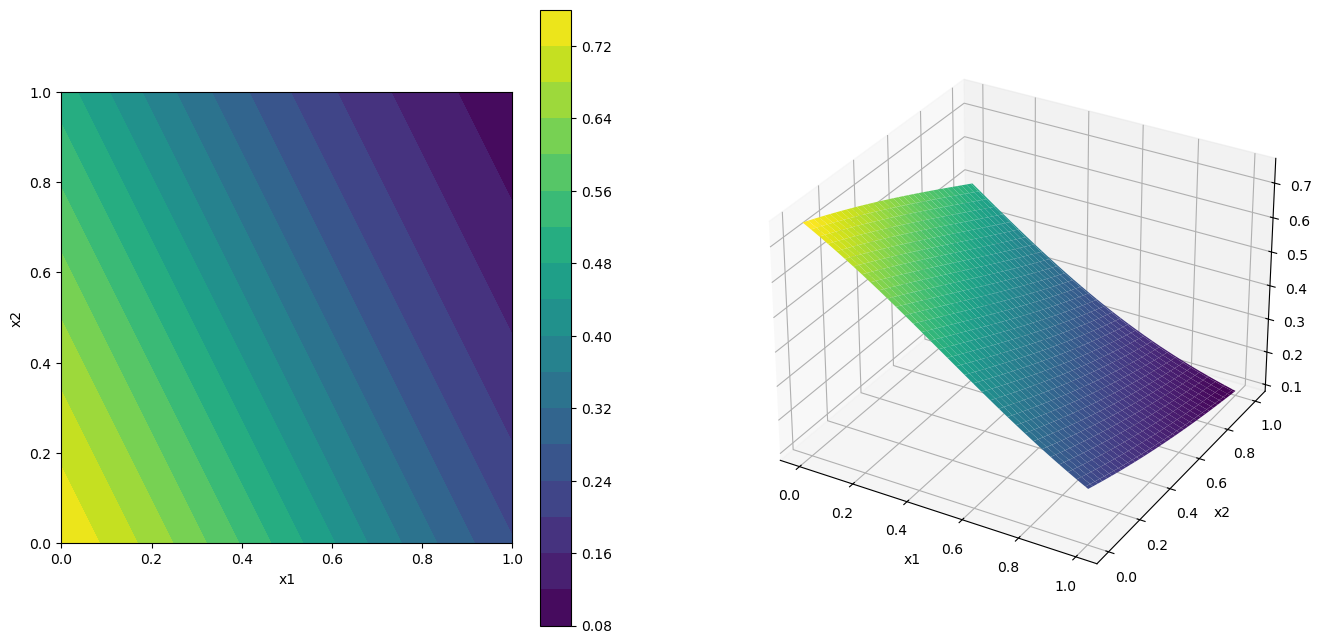

In [8]:
class ANDModel(nn.Module):
    def __init__(self, input_size):
        super(ANDModel, self).__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))
    
# モデルのインスタンス化
model_and = ANDModel(input_size=2)
print(model_and)
    
# オプティマイザの定義
optimizer = optim.SGD(model_and.parameters(), lr=1.5)

num_epochs = 1000

# 損失の履歴を保存するためのリスト
loss_history = []

# 学習
for epoch in range(num_epochs):
    total_loss = 0
    for input_data, target in training_data:
        optimizer.zero_grad()  # 勾配の初期化
        output = model_and(input_data)  # フォワードパス
        loss = criterion(output, target)  # 損失の計算
        loss.backward()  # バックワードパス（勾配の計算）
        optimizer.step()  # パラメータの更新
        total_loss += loss.item()
    loss_history.append(total_loss / len(training_data))
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss / len(training_data)}')

# 学習の推移をグラフ化
plt.plot(range(1, num_epochs + 1), loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

# 学習後のモデルの評価
with torch.no_grad():
    for input_data, _ in training_data:
        prediction = model_and(input_data)
        print(f'Input: {input_data.numpy()}, Predicted Output: {prediction.item()}')

## 結果を視覚的に出力
# x1とx2の生成
x1 = np.linspace(0, 1, 101)  # [0 0.1 ... 1.0]
x2 = np.linspace(0, 1, 101)  # [0 0.1 ... 1.0]
X1, X2 = np.meshgrid(x1, x2)

# 入力x1とx2の出力を計算しvalに代入
val = []

# perceptron の forward メソッドの戻り値が PyTorch テンソルなので numpy に変換
for v in x2:
    for u in x1:
        input_data = torch.tensor([u, v], dtype=torch.float32)
        output = model_and.forward(input_data).detach().numpy()
        val.append(output)

val = np.asarray(val)
val = val.reshape(X1.shape)


fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(121)
   
surf = ax.contourf(X1, X2, val, 20, cmap='viridis')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect('equal') 

ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X1, X2, val, cmap='viridis') 
ax.set_xlabel("x1")
ax.set_ylabel("x2")
fig.colorbar(surf)
plt.show()